In [1]:
from google.colab import files as colab_files
import os, json

for fname in ["train.json", "val.json", "test.json"]:
    for suffix in ["", " (1)", " (2)", " (3)"]:
        path = f"/content/{fname.replace('.json', suffix + '.json')}"
        if os.path.exists(path):
            os.remove(path)

print("Upload train.json, val.json, test.json from vigenere/ folder")
uploaded = colab_files.upload()

for fname in ["train.json", "val.json", "test.json"]:
    match = next((k for k in uploaded if fname.replace(".json","") in k), None)
    if match is None:
        print(f"ERROR: {fname} not found")
    else:
        with open(f"/content/{fname}", "wb") as f:
            f.write(uploaded[match])
        data = json.loads(uploaded[match])
        print(f"  {fname}: {len(data)} records  OK")

SAVE_DIR = "/content/causal_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Ready. SAVE_DIR={SAVE_DIR}")

Upload train.json, val.json, test.json from vigenere/ folder


Saving test.json to test.json
Saving train.json to train.json
Saving val.json to val.json
  train.json: 700 records  OK
  val.json: 150 records  OK
  test.json: 150 records  OK
Ready. SAVE_DIR=/content/causal_outputs


In [2]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'scikit-learn'], check=True)

import math, string, time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

VOCAB      = list(string.ascii_lowercase + string.digits) + ['<PAD>', '<UNK>']
C2I        = {c: i for i, c in enumerate(VOCAB)}
VOCAB_SIZE = len(VOCAB)
PAD_IDX    = C2I['<PAD>']
MAX_LEN    = 512
KEY        = "CIPHER"
KEY_LEN    = len(KEY)
ALPHA_IDS  = set(C2I[c] for c in string.ascii_lowercase)
print("Constants ready.")

Device: cuda
Constants ready.


In [3]:
def encode(text):
    ids = [C2I.get(c, C2I['<UNK>']) for c in text[:MAX_LEN]]
    ids += [PAD_IDX] * (MAX_LEN - len(ids))
    return torch.tensor(ids, dtype=torch.long)

def get_padding_mask(x):
    return x == PAD_IDX

def get_causal_mask(seq_len, device):

    mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
    return mask.bool()

class CipherDataset(Dataset):
    def __init__(self, split):
        path = f"/content/{split}.json"
        with open(path, encoding="utf-8") as f:
            records = json.load(f)
        self.pairs = []
        for r in records:
            enc   = ''.join(c for c in r['ciphertext'].lower() if c in C2I)
            plain = ''.join(c for c in r['plaintext'].lower()  if c in C2I)
            if len(enc) < 50 or len(plain) < 50:
                continue
            self.pairs.append((encode(enc), encode(plain)))
        print(f"  {split}: {len(self.pairs)} pairs")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        return self.pairs[i]

train_loader = DataLoader(CipherDataset("train"), batch_size=32,
                          shuffle=True,  num_workers=2)
val_loader   = DataLoader(CipherDataset("val"),   batch_size=32,
                          shuffle=False, num_workers=2)
test_loader  = DataLoader(CipherDataset("test"),  batch_size=32,
                          shuffle=False, num_workers=2)
print("Data ready.")

  train: 700 pairs
  val: 150 pairs
  test: 150 pairs
Data ready.


In [4]:
class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class RoPE(nn.Module):

    def __init__(self, d_model, max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        inv_freq = 1.0 / (
            10000 ** (torch.arange(0, d_model, 2).float() / d_model)
        )
        self.register_buffer('inv_freq', inv_freq)

    def forward(self, x):
        B, T, D = x.shape
        t      = torch.arange(T, device=x.device).float()
        freqs  = torch.outer(t, self.inv_freq)
        cos_   = freqs.cos().unsqueeze(0)
        sin_   = freqs.sin().unsqueeze(0)
        x1, x2 = x[..., 0::2], x[..., 1::2]
        x_rot   = torch.cat(
            [x1 * cos_ - x2 * sin_, x1 * sin_ + x2 * cos_], dim=-1
        )
        return self.dropout(x_rot)

print("PE classes defined.")

PE classes defined.


In [5]:
class TransformerLayer(nn.Module):

    def __init__(self, d_model=256, nhead=8, dim_ff=1024, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(
            d_model, nhead, dropout=dropout, batch_first=True
        )
        self.ff    = nn.Sequential(
            nn.Linear(d_model, dim_ff), nn.ReLU(),
            nn.Linear(dim_ff, d_model)
        )
        self.norm1          = nn.LayerNorm(d_model)
        self.norm2          = nn.LayerNorm(d_model)
        self.drop           = nn.Dropout(dropout)
        self.stored_weights = None

    def forward(self, x, key_padding_mask=None, attn_mask=None):
        out, w = self.attn(
            x, x, x,
            key_padding_mask = key_padding_mask,
            attn_mask        = attn_mask,
            need_weights     = True,
            average_attn_weights = True
        )
        self.stored_weights = w.detach().cpu()
        x = self.norm1(x + self.drop(out))
        x = self.norm2(x + self.drop(self.ff(x)))
        return x


class CausalTransformer(nn.Module):

    def __init__(self, mode="bidirectional", vocab_size=VOCAB_SIZE,
                 d_model=256, nhead=8, num_layers=4,
                 dim_ff=1024, dropout=0.1):
        super().__init__()
        assert mode in ("bidirectional", "causal", "causal_rope"),             f"Unknown mode: {mode}"
        self.mode  = mode
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pe    = (RoPE(d_model, dropout=dropout)
                      if mode == "causal_rope"
                      else SinusoidalPE(d_model, dropout=dropout))
        self.layers = nn.ModuleList([
            TransformerLayer(d_model, nhead, dim_ff, dropout)
            for _ in range(num_layers)
        ])
        self.proj  = nn.Linear(d_model, vocab_size)
        self.scale = math.sqrt(d_model)

    def forward(self, x, key_padding_mask=None):
        x = self.pe(self.embed(x) * self.scale)
        # build causal mask if needed
        attn_mask = None
        if self.mode in ("causal", "causal_rope"):
            attn_mask = get_causal_mask(x.size(1), x.device)
        for layer in self.layers:
            x = layer(x,
                      key_padding_mask=key_padding_mask,
                      attn_mask=attn_mask)
        return self.proj(x)

    def get_attention_weights(self):
        return [layer.stored_weights for layer in self.layers]


class LSTMDecryptor(nn.Module):

    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=128,
                 hidden=256, num_layers=2, dropout=0.1):
        super().__init__()
        self.embed         = nn.Embedding(vocab_size, embed_dim,
                                          padding_idx=PAD_IDX)
        self.lstm          = nn.LSTM(
            embed_dim, hidden, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.proj          = nn.Linear(hidden * 2, vocab_size)
        self.stored_hidden = None

    def forward(self, x):
        out, _             = self.lstm(self.embed(x))
        self.stored_hidden = out.detach().cpu()
        return self.proj(out)

print("Models defined.")

Models defined.


In [6]:
CRITERION = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

def train_epoch(model, loader, optimizer, is_tf):
    model.train()
    total = 0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()
        out = (model(src, key_padding_mask=get_padding_mask(src))
               if is_tf else model(src))
        loss = CRITERION(out.reshape(-1, VOCAB_SIZE), tgt.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def evaluate(model, loader, is_tf):
    model.eval()
    correct = total = loss_sum = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            out = (model(src, key_padding_mask=get_padding_mask(src))
                   if is_tf else model(src))
            loss_sum += CRITERION(
                out.reshape(-1, VOCAB_SIZE), tgt.reshape(-1)
            ).item()
            pred     = out.argmax(-1)
            mask     = tgt != PAD_IDX
            correct += (pred[mask] == tgt[mask]).sum().item()
            total   += mask.sum().item()
    return loss_sum / len(loader), correct / total

def run_training(name, model, is_tf, epochs=30):
    model   = model.to(DEVICE)
    opt     = torch.optim.Adam(model.parameters(), lr=1e-3)
    sched   = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=epochs
    )
    best_val_loss = float('inf')
    history       = []

    print(f"\n{'='*55}")
    print(f"  {name.upper()}")
    print(f"  Params: {sum(p.numel() for p in model.parameters()):,}")
    print(f"{'='*55}")

    for epoch in range(1, epochs + 1):
        train_epoch(model, train_loader, opt, is_tf)
        val_loss, val_acc = evaluate(model, val_loader, is_tf)
        sched.step()
        history.append(round(val_acc * 100, 2))
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(),
                       os.path.join(SAVE_DIR, f"{name}.pt"))
        if epoch % 5 == 0:
            print(f"  Epoch {epoch:2d}  val_acc={val_acc*100:.2f}%")

    model.load_state_dict(
        torch.load(os.path.join(SAVE_DIR, f"{name}.pt"),
                   map_location=DEVICE)
    )
    model.eval()
    _, test_acc = evaluate(model, test_loader, is_tf)
    print(f"  DONE  test_acc={test_acc*100:.2f}%")
    return model, history, round(test_acc * 100, 2)

print("Training helpers ready.")

Training helpers ready.


In [7]:
RESULTS_PATH = os.path.join(SAVE_DIR, "causal_results.json")

if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH) as f:
        all_results = json.load(f)
    print(f"Resuming — {len(all_results)} conditions done.")
else:
    all_results = {}

trained_models = {}

conditions = [
    ("bidirectional", CausalTransformer(mode="bidirectional"), True),
    ("causal",        CausalTransformer(mode="causal"),        True),
    ("causal_rope",   CausalTransformer(mode="causal_rope"),   True),
    ("lstm",          LSTMDecryptor(),                          False),
]

for name, model, is_tf in conditions:
    if name in all_results:
        print(f"Skipping {name} — test={all_results[name]['test_acc']}%")
        # reload
        if is_tf:
            m = CausalTransformer(
                mode=name if name != "lstm" else "bidirectional"
            ).to(DEVICE)
        else:
            m = LSTMDecryptor().to(DEVICE)
        pt = os.path.join(SAVE_DIR, f"{name}.pt")
        if os.path.exists(pt):
            m.load_state_dict(torch.load(pt, map_location=DEVICE))
        m.eval()
        trained_models[name] = m
        continue

    m, history, test_acc = run_training(name, model, is_tf, epochs=30)
    trained_models[name] = m
    all_results[name] = {
        "test_acc": test_acc,
        "history" : history,
    }
    with open(RESULTS_PATH, "w") as f:
        json.dump(all_results, f, indent=2)

print("\nAll conditions complete.")


  BIDIRECTIONAL
  Params: 3,178,534
  Epoch  5  val_acc=38.95%
  Epoch 10  val_acc=37.83%
  Epoch 15  val_acc=39.29%
  Epoch 20  val_acc=38.98%
  Epoch 25  val_acc=39.28%
  Epoch 30  val_acc=39.43%
  DONE  test_acc=39.24%

  CAUSAL
  Params: 3,178,534
  Epoch  5  val_acc=39.46%
  Epoch 10  val_acc=39.25%
  Epoch 15  val_acc=39.74%
  Epoch 20  val_acc=39.73%
  Epoch 25  val_acc=39.73%
  Epoch 30  val_acc=39.97%
  DONE  test_acc=39.91%

  CAUSAL_ROPE
  Params: 3,178,534
  Epoch  5  val_acc=39.50%
  Epoch 10  val_acc=43.23%
  Epoch 15  val_acc=47.85%
  Epoch 20  val_acc=54.13%
  Epoch 25  val_acc=56.33%
  Epoch 30  val_acc=56.82%
  DONE  test_acc=57.24%

  LSTM
  Params: 2,391,846
  Epoch  5  val_acc=97.20%
  Epoch 10  val_acc=99.83%
  Epoch 15  val_acc=99.90%
  Epoch 20  val_acc=99.91%
  Epoch 25  val_acc=99.92%
  Epoch 30  val_acc=99.92%
  DONE  test_acc=99.90%

All conditions complete.


In [8]:
with open(RESULTS_PATH) as f:
    all_results = json.load(f)

lstm_acc = all_results["lstm"]["test_acc"]

descriptions = {
    "bidirectional" : "Full bidirectional attention + sinusoidal PE (baseline)",
    "causal"        : "Causal (left-to-right) attention + sinusoidal PE",
    "causal_rope"   : "Causal attention + RoPE (best PE from P3)",
    "lstm"          : "BiLSTM reference",
}

order = ["bidirectional", "causal", "causal_rope", "lstm"]

print("=" * 70)
print("  CAUSAL MASKING ABLATION RESULTS ON VIGENERE")
print("=" * 70)
print(f"  Architecture: 4 layers, d_model=256, nhead=8")
print(f"  LSTM reference: {lstm_acc:.2f}%  |  Chance: ~2.6%")
print("=" * 70)
print(f"\n{'Condition':<16} {'Test Acc':>10}  {'vs Bidirectional':>18}  "
      f"Description")
print("-" * 70)

baseline = all_results["bidirectional"]["test_acc"]
for name in order:
    r    = all_results[name]
    diff = r['test_acc'] - baseline if name != "bidirectional" else 0
    sign = f"+{diff:.2f}pp" if diff > 0 else (f"{diff:.2f}pp"
                                               if diff < 0 else "baseline")
    print(f"  {name:<14} {r['test_acc']:>9.2f}%  {sign:>18}  "
          f"{descriptions[name]}")
print("=" * 70)

  CAUSAL MASKING ABLATION RESULTS ON VIGENERE
  Architecture: 4 layers, d_model=256, nhead=8
  LSTM reference: 99.90%  |  Chance: ~2.6%

Condition          Test Acc    vs Bidirectional  Description
----------------------------------------------------------------------
  bidirectional      39.24%            baseline  Full bidirectional attention + sinusoidal PE (baseline)
  causal             39.91%             +0.67pp  Causal (left-to-right) attention + sinusoidal PE
  causal_rope        57.24%            +18.00pp  Causal attention + RoPE (best PE from P3)
  lstm               99.90%            +60.66pp  BiLSTM reference


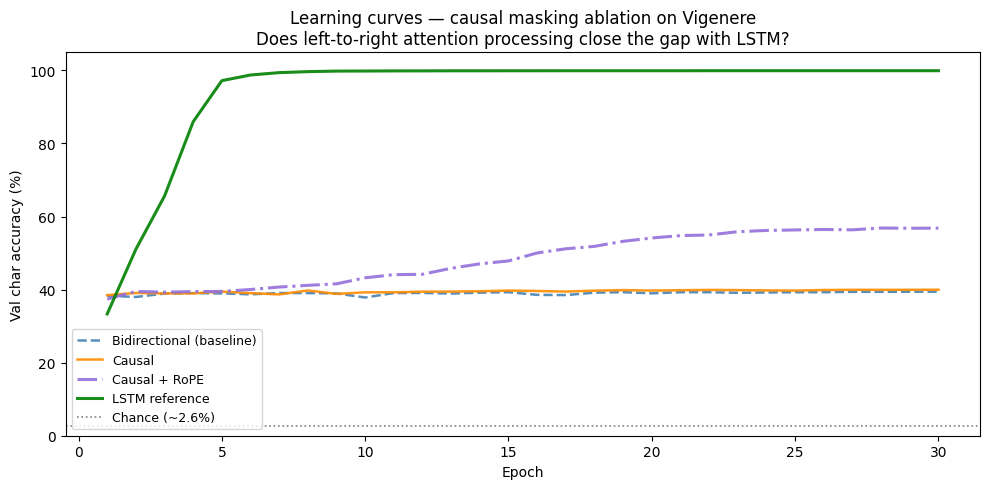

Saved: fig_causal_curves.pdf


In [9]:
with open(RESULTS_PATH) as f:
    all_results = json.load(f)

colors = {
    "bidirectional" : "steelblue",
    "causal"        : "darkorange",
    "causal_rope"   : "mediumpurple",
    "lstm"          : "green",
}
labels = {
    "bidirectional" : "Bidirectional (baseline)",
    "causal"        : "Causal",
    "causal_rope"   : "Causal + RoPE",
    "lstm"          : "LSTM reference",
}
ls = {
    "bidirectional" : "--",
    "causal"        : "-",
    "causal_rope"   : "-.",
    "lstm"          : "-",
}

fig, ax = plt.subplots(figsize=(10, 5))
for name in ["bidirectional", "causal", "causal_rope", "lstm"]:
    if name not in all_results:
        continue
    hist = all_results[name]["history"]
    ax.plot(range(1, len(hist)+1), hist,
            color=colors[name], linestyle=ls[name],
            linewidth=2.2 if name in ["causal_rope","lstm"] else 1.8,
            label=labels[name], alpha=0.9)

ax.axhline(2.6, color="gray", linestyle=":", linewidth=1.2,
           label="Chance (~2.6%)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Val char accuracy (%)")
ax.set_ylim(0, 105)
ax.set_title(
    "Learning curves — causal masking ablation on Vigenere\n"
    "Does left-to-right attention processing close the gap with LSTM?"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "fig_causal_curves.pdf"))
plt.show()
print("Saved: fig_causal_curves.pdf")

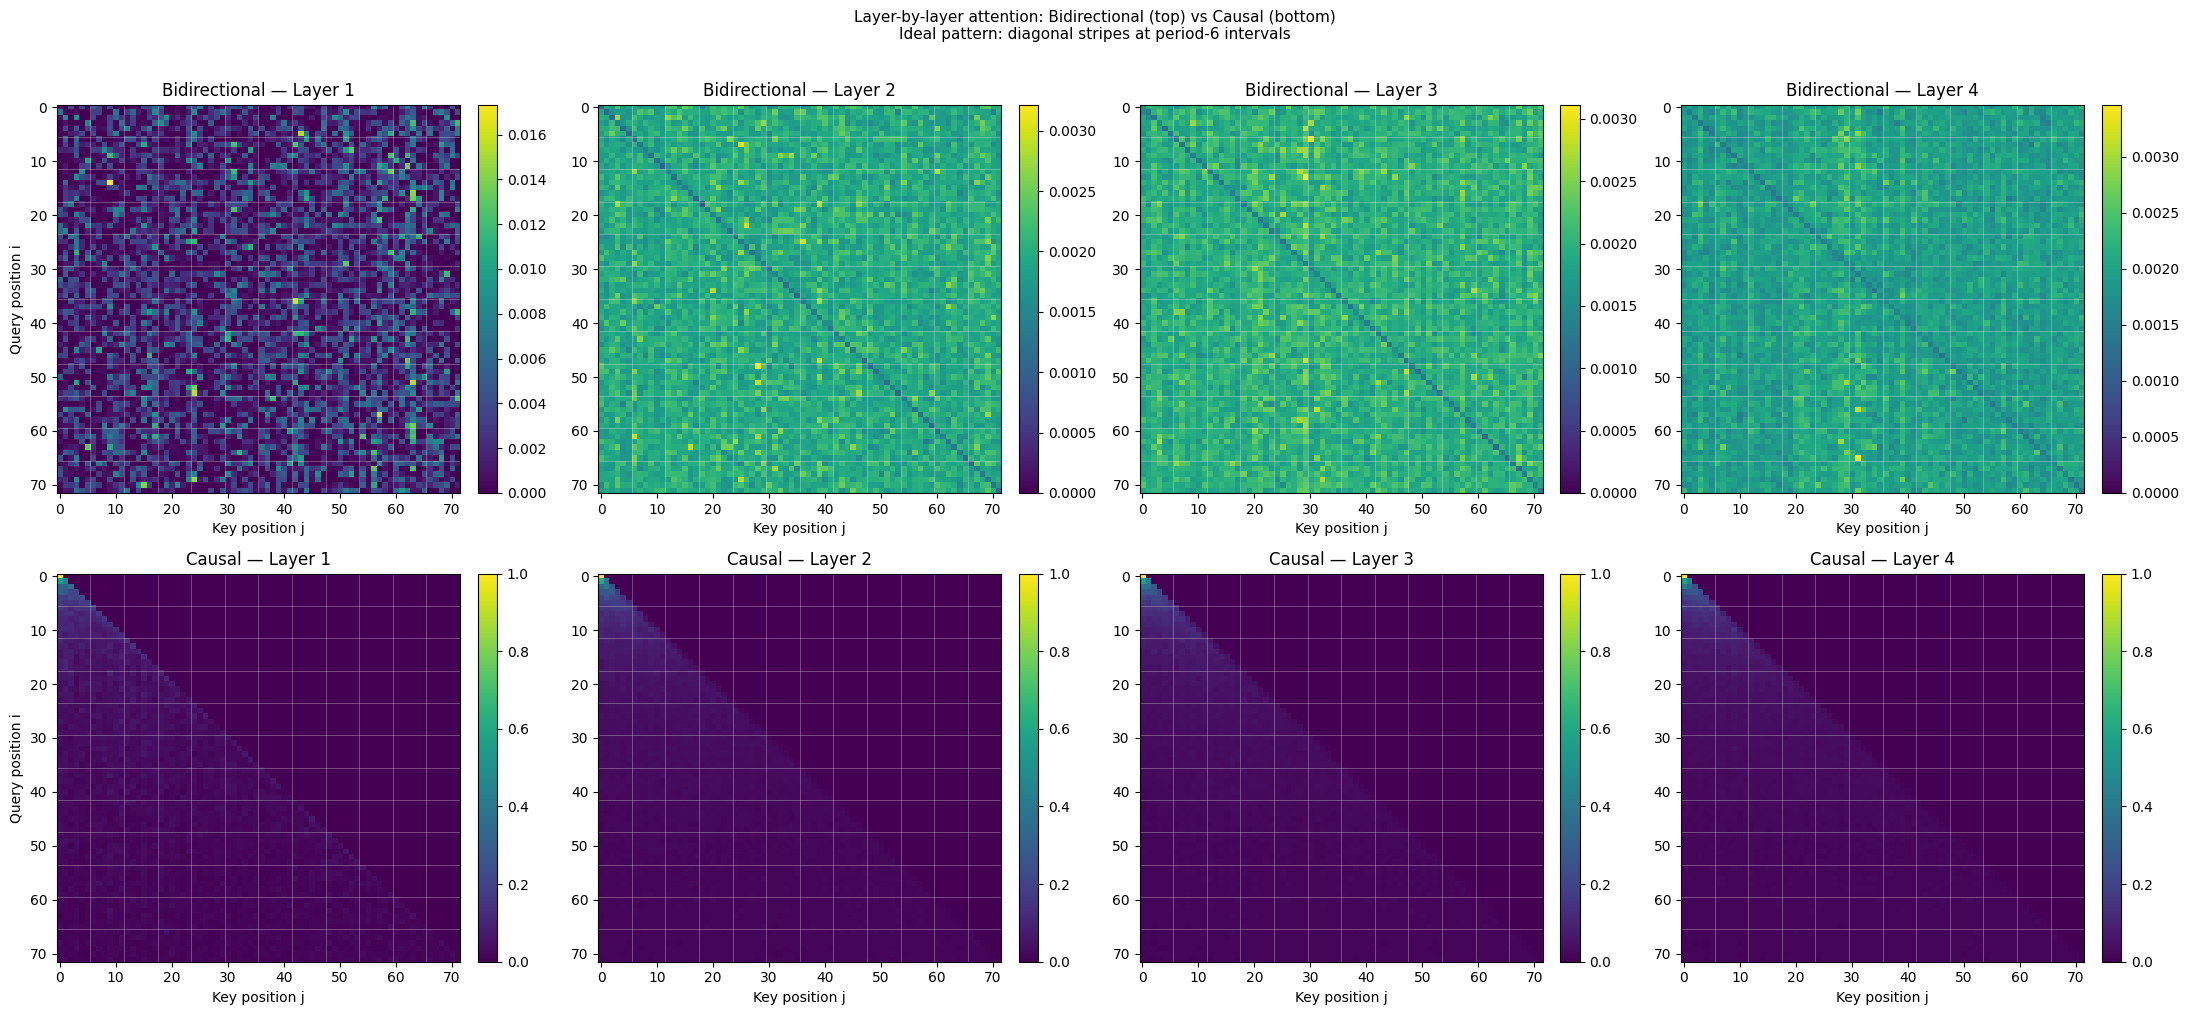

Saved: fig_causal_attn_heatmaps.pdf


In [10]:
VIZ_LEN = 72

ds_val    = val_loader.dataset
src_batch = torch.stack([ds_val[i][0] for i in range(32)])

def get_attn_weights(model, src):
    src = src.to(DEVICE)
    with torch.no_grad():
        model(src, key_padding_mask=get_padding_mask(src))
    return model.get_attention_weights()

bidir_weights = get_attn_weights(trained_models["bidirectional"], src_batch)
causal_weights = get_attn_weights(trained_models["causal"], src_batch)

ideal = np.zeros((VIZ_LEN, VIZ_LEN))
for q in range(VIZ_LEN):
    cols = [k for k in range(q+1) if k % KEY_LEN == q % KEY_LEN]
    if cols:
        ideal[q, cols] = 1.0 / len(cols)

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle(
    "Layer-by-layer attention: Bidirectional (top) vs Causal (bottom)\n"
    "Ideal pattern: diagonal stripes at period-6 intervals",
    fontsize=11, y=1.01
)

for row, (weights, label) in enumerate([
    (bidir_weights,  "Bidirectional"),
    (causal_weights, "Causal"),
]):
    for col in range(4):
        ax  = axes[row, col]
        w   = weights[col].mean(0).numpy()[:VIZ_LEN, :VIZ_LEN]
        im  = ax.imshow(w, cmap="viridis", aspect="auto", vmin=0)
        ax.set_title(f"{label} — Layer {col+1}")
        ax.set_xlabel("Key position j")
        if col == 0:
            ax.set_ylabel("Query position i")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        for tick in range(0, VIZ_LEN, KEY_LEN):
            ax.axvline(tick - 0.5, color="white", linewidth=0.4, alpha=0.5)
            ax.axhline(tick - 0.5, color="white", linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "fig_causal_attn_heatmaps.pdf"))
plt.show()
print("Saved: fig_causal_attn_heatmaps.pdf")

In [11]:
def extract_hidden_tf(model, loader, n_batches=15):
    all_h, all_labels = [], []
    for i, (src, tgt) in enumerate(loader):
        if i >= n_batches:
            break
        src_cpu  = src.clone()
        src      = src.to(DEVICE)
        captured = []
        handle   = model.layers[-1].register_forward_hook(
            lambda m, inp, out: captured.append(out.detach().cpu())
        )
        with torch.no_grad():
            model(src, key_padding_mask=get_padding_mask(src))
        handle.remove()

        hidden  = captured[0]
        B, T, D = hidden.shape
        labels  = np.full((B, T), -1, dtype=int)
        for b in range(B):
            ki = 0
            for t in range(T):
                if src_cpu[b, t].item() in ALPHA_IDS:
                    labels[b, t] = ki % KEY_LEN
                    ki += 1

        h_flat = hidden.reshape(-1, D).numpy()
        l_flat = labels.reshape(-1)
        valid  = l_flat >= 0
        all_h.append(h_flat[valid])
        all_labels.append(l_flat[valid])

    return np.concatenate(all_h), np.concatenate(all_labels)

def run_probe(X, y):
    split  = int(0.8 * len(X))
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X[:split])
    X_te   = scaler.transform(X[split:])
    clf    = LogisticRegression(max_iter=1000, C=1.0, n_jobs=-1)
    clf.fit(X_tr, y[:split])
    return accuracy_score(y[split:], clf.predict(X_te)) * 100

print("Running linear probes...")
print(f"Chance = {100/KEY_LEN:.1f}%\n")

probe_results = {}
for name in ["bidirectional", "causal", "causal_rope"]:
    if name not in trained_models:
        continue
    X, y = extract_hidden_tf(trained_models[name], val_loader)
    acc  = run_probe(X, y)
    probe_results[name] = round(acc, 2)
    print(f"  {name:<16} probe={acc:.2f}%")

print(f"\n{'Condition':<18} {'Task Acc':>10}  {'Probe Acc':>10}  "
      f"{'vs Chance':>10}")
print("-" * 55)
for name in ["bidirectional", "causal", "causal_rope"]:
    task  = all_results[name]["test_acc"]
    probe = probe_results.get(name, "N/A")
    vs_c  = f"+{probe - 100/KEY_LEN:.1f}pp" if isinstance(probe, float) else "N/A"
    print(f"  {name:<16} {task:>9.2f}%  {probe:>9.2f}%  {vs_c:>10}")
print(f"  {'lstm':<16} {all_results['lstm']['test_acc']:>9.2f}%  "
      f"{'99.82':>9}%  {'+83.1pp':>10}")
print(f"  {'Chance':<16} {'---':>9}   {100/KEY_LEN:>9.1f}%")

Running linear probes...
Chance = 16.7%

  bidirectional    probe=37.01%
  causal           probe=37.46%
  causal_rope      probe=44.66%

Condition            Task Acc   Probe Acc   vs Chance
-------------------------------------------------------
  bidirectional        39.24%      37.01%     +20.3pp
  causal               39.91%      37.46%     +20.8pp
  causal_rope          57.24%      44.66%     +28.0pp
  lstm                 99.90%      99.82%     +83.1pp
  Chance                 ---        16.7%


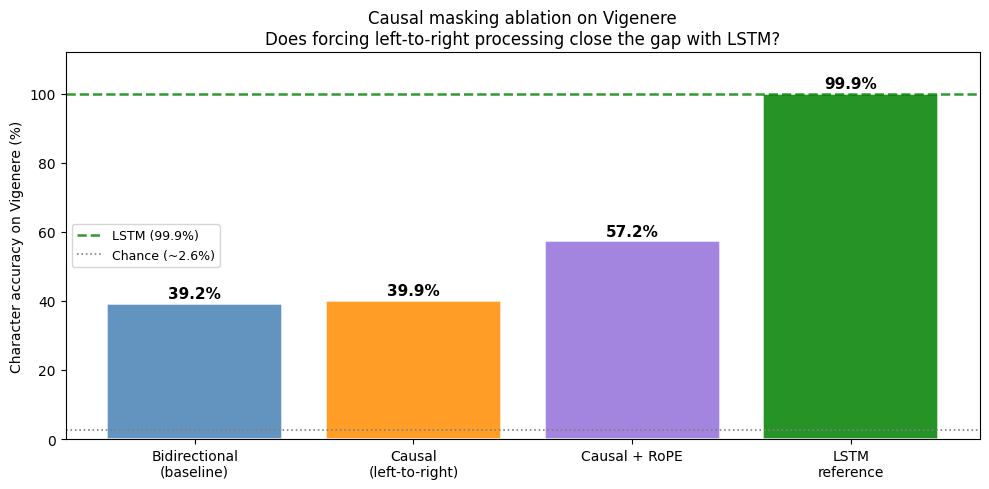

Saved: fig_causal_summary.pdf


In [12]:
with open(RESULTS_PATH) as f:
    all_results = json.load(f)

order  = ["bidirectional", "causal", "causal_rope", "lstm"]
accs   = [all_results[k]["test_acc"] for k in order]
colors_bar = ["steelblue", "darkorange", "mediumpurple", "green"]
xlabels = ["Bidirectional\n(baseline)", "Causal\n(left-to-right)",
           "Causal + RoPE", "LSTM\nreference"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(xlabels, accs, color=colors_bar, alpha=0.85,
              edgecolor="white", linewidth=1.2)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f"{acc:.1f}%", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.axhline(all_results["lstm"]["test_acc"],
           color="green", linestyle="--", linewidth=1.8,
           label=f"LSTM ({all_results['lstm']['test_acc']:.1f}%)",
           alpha=0.8)
ax.axhline(2.6, color="gray", linestyle=":", linewidth=1.2,
           label="Chance (~2.6%)")

ax.set_ylabel("Character accuracy on Vigenere (%)")
ax.set_ylim(0, 112)
ax.set_title(
    "Causal masking ablation on Vigenere\n"
    "Does forcing left-to-right processing close the gap with LSTM?"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "fig_causal_summary.pdf"))
plt.show()
print("Saved: fig_causal_summary.pdf")

In [13]:
from google.colab import files as colab_files

for fname in ["causal_results.json",
              "fig_causal_summary.pdf",
              "fig_causal_curves.pdf",
              "fig_causal_attn_heatmaps.pdf"]:
    fpath = os.path.join(SAVE_DIR, fname)
    if os.path.exists(fpath):
        colab_files.download(fpath)
        print(f"Downloaded: {fname}")
    else:
        print(f"Not found: {fname}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: causal_results.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: fig_causal_curves.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: fig_causal_attn_heatmaps.pdf
